## Test EfficientNetV2M

In [1]:
%pip install matplotlib 
%pip install numpy --quiet
%pip install tensorflow --quiet
%pip install tabulate --quiet

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/04/a1/4571fc46e7702de8d0c2dc54ad1b2f8e29328dea3ee90831181f7353d93c/matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ----------------------------- -------- 41.0/52.8 kB 991.0 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 926.0 kB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/19/e8/6026ed58a64563186a9ee3f29f41261fd1828f527dd93d33b60feca63352/contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Obtaining dependency information for fonttools>=4.22.0 from http

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib
from tabulate import tabulate

In [ ]:
DATA_DIR = pathlib.Path("../../datasets/livrable1")

..\..\datasets\livrable1


In [11]:
num_skipped = 0

for image in DATA_DIR.glob("**/*.*"):
    try:
        img = PIL.Image.open(image)
        img.verify()

        img_bytes = tf.io.read_file(str(image))
        decoded_img = tf.io.decode_image(img_bytes)
    except (IOError, SyntaxError, tf.errors.InvalidArgumentError) as e:
        print("Suppression de l'image corrompue : ", image)
        num_skipped += 1
        image.unlink()

print(f"Nombre d'images corrompues supprimées : {num_skipped}")

Suppression de l'image corrompue :  ..\..\datasets\livrable1\Painting\Painting\painting_02662.jpg
Suppression de l'image corrompue :  ..\..\datasets\livrable1\Schematics\Schematics\desktop.ini
Nombre d'images corrompues supprimées : 2


In [14]:
# Conversion des PNG en JPEG
for image in DATA_DIR.glob("**/*.png"):
    try:
        img = PIL.Image.open(image)
        rgb_img = img.convert("RGB")
        new_image_path = image.with_suffix(".jpg")
        rgb_img.save(new_image_path, "JPEG")
        image.unlink()
    except (IOError, SyntaxError) as e:
        print("Erreur lors de la conversion de l'image : ", image)

In [16]:
import pathlib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

DATA_DIR = pathlib.Path("../../datasets/livrable1")
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
BATCH_SIZE = 8
SEED = 123

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    validation_split=0.2,
    subset="both",
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)

preprocess_input = tf.keras.applications.efficientnet_v2.preprocess_input
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda images, labels: (preprocess_input(tf.cast(images, tf.float32)), labels),
    num_parallel_calls=AUTOTUNE,
).cache().prefetch(AUTOTUNE)

val_ds = val_ds.map(
    lambda images, labels: (preprocess_input(tf.cast(images, tf.float32)), labels),
    num_parallel_calls=AUTOTUNE,
).cache().prefetch(AUTOTUNE)

base_model = tf.keras.applications.EfficientNetV2M(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3),
)
base_model.trainable = False

inputs = keras.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

for images, labels in train_ds.take(1):
    predictions = model(images)
    print("classes:", class_names)
    print("batch:", images.shape, labels.shape)
    print("predictions:", predictions.shape)

model.summary()

Found 41398 files belonging to 5 classes.
Using 33119 files for training.
Using 8279 files for validation.
classes: ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
batch: (8, 224, 224, 3) (8,)
predictions: (8, 5)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (None, 7, 7, 1280)     │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,156,793 (202.78 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 53,150,388 (202.75 MB)

In [17]:
EPOCHS_HEAD = 3
EPOCHS_FINE_TUNE = 2
FINE_TUNE_AT = len(base_model.layers) - 30

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-6,
    ),
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks,
)

base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base_model.layers[FINE_TUNE_AT:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

history_fine_tune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD + EPOCHS_FINE_TUNE,
    initial_epoch=history_head.epoch[-1] + 1,
    callbacks=callbacks,
)

history = history_head
history_fine_tune

Epoch 1/3
4140/4140 ━━━━━━━━━━━━━━━━━━━━ 1489s 356ms/step - accuracy: 0.8660 - loss: 0.4967 - val_accuracy: 0.9367 - val_loss: 0.2677 - learning_rate: 1.0000e-04
Epoch 2/3
4140/4140 ━━━━━━━━━━━━━━━━━━━━ 1374s 332ms/step - accuracy: 0.9428 - loss: 0.2226 - val_accuracy: 0.9489 - val_loss: 0.1882 - learning_rate: 1.0000e-04
Epoch 3/3
4140/4140 ━━━━━━━━━━━━━━━━━━━━ 1445s 349ms/step - accuracy: 0.9522 - loss: 0.1731 - val_accuracy: 0.9556 - val_loss: 0.1593 - learning_rate: 1.0000e-04
Epoch 4/5
4140/4140 ━━━━━━━━━━━━━━━━━━━━ 1603s 383ms/step - accuracy: 0.9721 - loss: 0.0866 - val_accuracy: 0.9784 - val_loss: 0.0695 - learning_rate: 1.0000e-05
Epoch 5/5
4140/4140 ━━━━━━━━━━━━━━━━━━━━ 1636s 395ms/step - accuracy: 0.9823 - loss: 0.0531 - val_accuracy: 0.9830 - val_loss: 0.0601 - learning_rate: 1.0000e-05


Found 41398 files belonging to 5 classes.
Using 8279 files for validation.
Exemples de prédictions sur le jeu de validation :
- vrai: Text | prédit: Text | confiance: 1.000
- vrai: Schematics | prédit: Schematics | confiance: 1.000
- vrai: Text | prédit: Text | confiance: 1.000
- vrai: Painting | prédit: Painting | confiance: 1.000
- vrai: Text | prédit: Text | confiance: 0.998


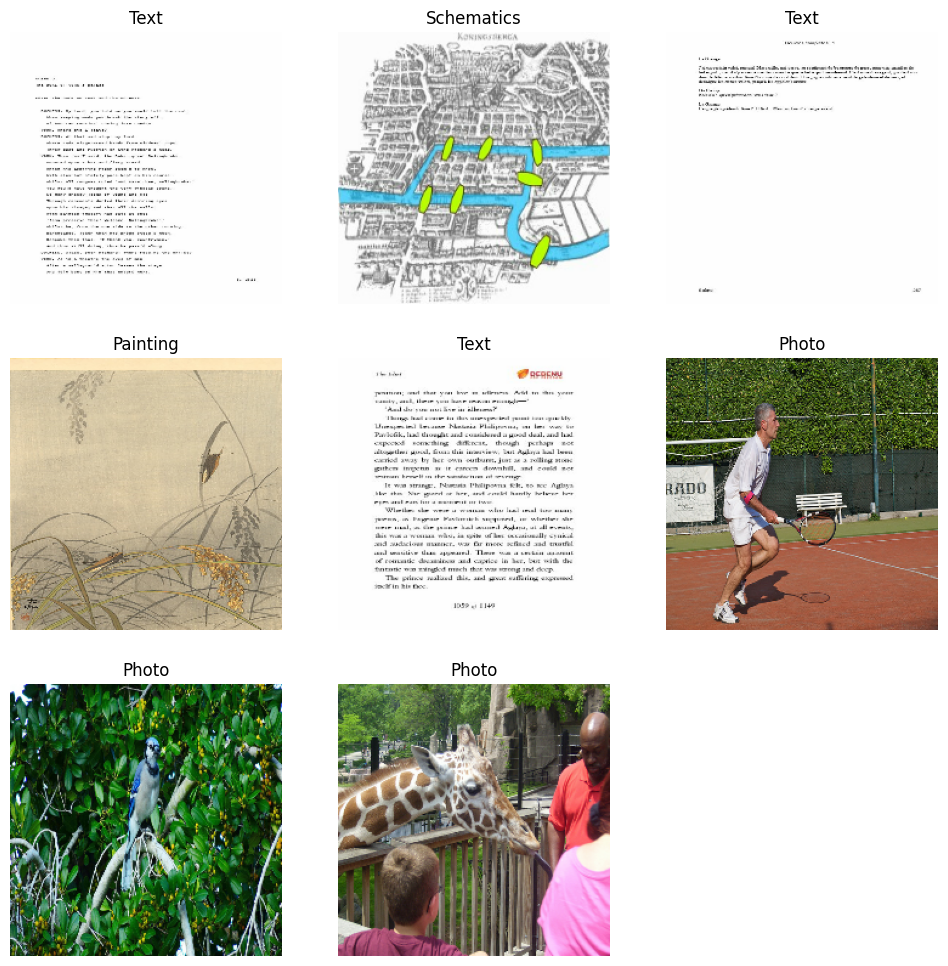

In [18]:
import matplotlib.pyplot as plt

raw_display_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
)

for raw_images_batch, labels_batch in raw_display_ds.take(1):
    processed_images_batch = preprocess_input(tf.cast(raw_images_batch, tf.float32))
    scores = model.predict(processed_images_batch, verbose=0)
    predicted_indices = tf.argmax(scores, axis=1)

    print("Exemples de prédictions sur le jeu de validation :")
    for index in range(min(5, raw_images_batch.shape[0])):
        true_label = class_names[int(labels_batch[index])]
        predicted_label = class_names[int(predicted_indices[index])]
        confidence = float(tf.reduce_max(scores[index]))
        print(f"- vrai: {true_label} | prédit: {predicted_label} | confiance: {confidence:.3f}")

    plt.figure(figsize=(12, 12))
    for index in range(min(9, raw_images_batch.shape[0])):
        ax = plt.subplot(3, 3, index + 1)
        plt.imshow(tf.cast(raw_images_batch[index], tf.uint8))
        plt.title(f"{class_names[int(predicted_indices[index])]}")
        plt.axis("off")

Nombre d'images dans datasets/final : 13
Prédictions sur datasets/final :
- image: 1.png | prédit: Schematics | confiance: 0.593
- image: 10.jpg | prédit: Photo | confiance: 0.986
- image: 11.jpg | prédit: Painting | confiance: 0.967
- image: 12.jpg | prédit: Painting | confiance: 0.826
- image: 13.jpg | prédit: Photo | confiance: 0.758
- image: 2.png | prédit: Photo | confiance: 0.994
- image: 3.png | prédit: Schematics | confiance: 0.925
- image: 4.jpg | prédit: Photo | confiance: 0.997
- image: 5.jpg | prédit: Photo | confiance: 0.594
- image: 6.jpg | prédit: Painting | confiance: 1.000
- image: 7.jpg | prédit: Painting | confiance: 0.829
- image: 8.jpg | prédit: Sketch | confiance: 0.693
- image: 9.jpg | prédit: Sketch | confiance: 0.988


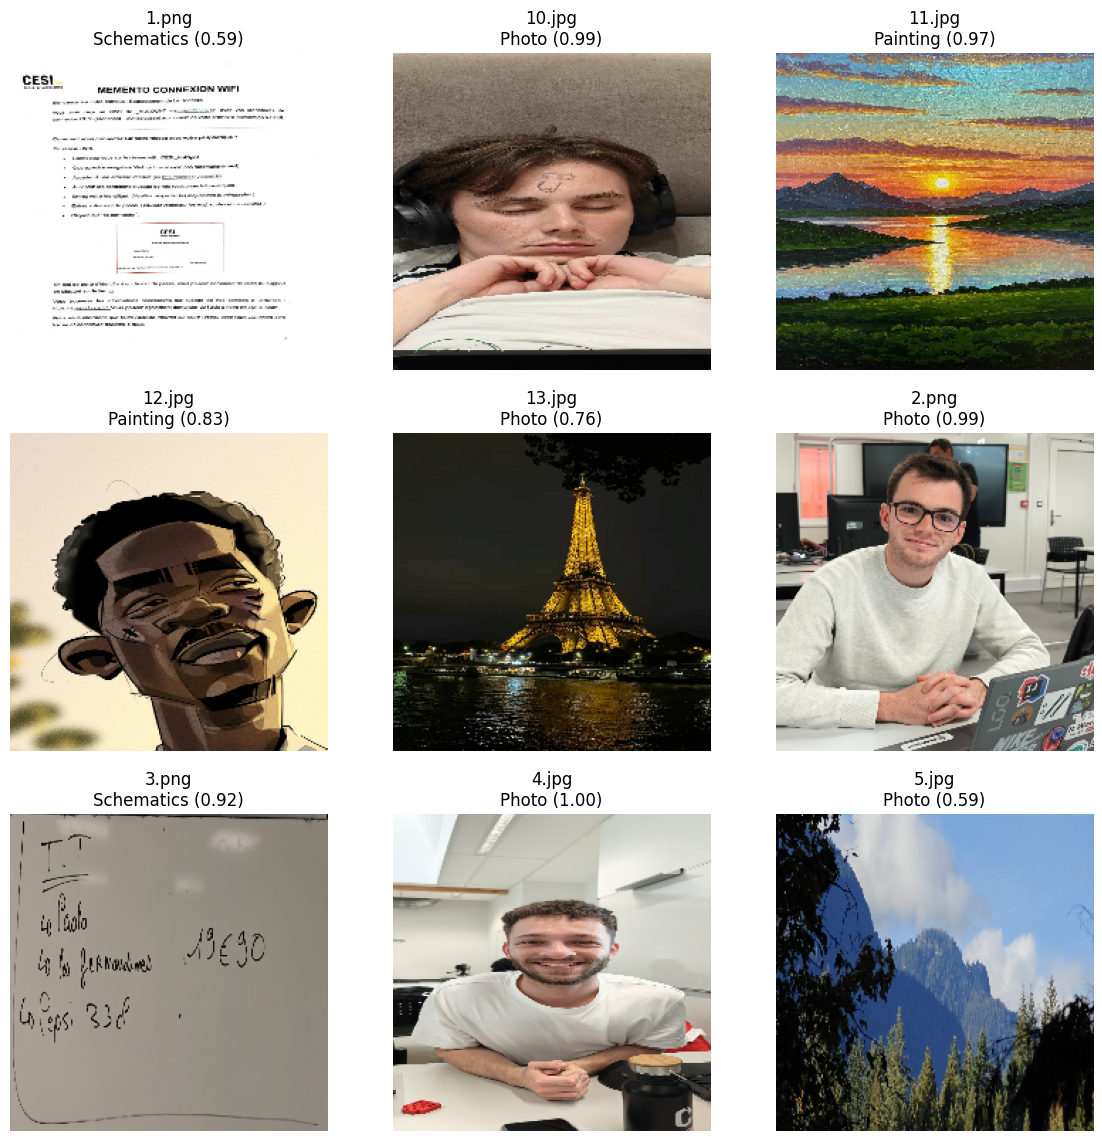

In [20]:
FINAL_DIR = pathlib.Path("../../datasets/final")
final_image_paths = sorted(
    [path for path in FINAL_DIR.glob("*.*") if path.suffix.lower() in {".jpg", ".jpeg", ".png"}]
)

print("Nombre d'images dans datasets/final :", len(final_image_paths))

final_raw_images = []
for image_path in final_image_paths:
    image_bytes = tf.io.read_file(str(image_path))
    image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, (IMAGE_HEIGHT, IMAGE_WIDTH))
    final_raw_images.append(image)

final_raw_images = tf.stack(final_raw_images)
final_processed_images = preprocess_input(tf.cast(final_raw_images, tf.float32))
final_scores = model.predict(final_processed_images, verbose=0)
final_predicted_indices = tf.argmax(final_scores, axis=1)
final_confidences = tf.reduce_max(final_scores, axis=1)

print("Prédictions sur datasets/final :")
for index in range(len(final_image_paths)):
    print(
        f"- image: {final_image_paths[index].name} | "
        f"prédit: {class_names[int(final_predicted_indices[index])]} | "
        f"confiance: {float(final_confidences[index]):.3f}"
    )

plt.figure(figsize=(14, 14))
for index in range(min(9, len(final_image_paths))):
    ax = plt.subplot(3, 3, index + 1)
    plt.imshow(tf.cast(final_raw_images[index], tf.uint8))
    plt.title(
        f"{final_image_paths[index].name}\n"
        f"{class_names[int(final_predicted_indices[index])]} ({float(final_confidences[index]):.2f})"
    )
    plt.axis("off")